# Spam Message Detection Project

This notebook tells the story of a spam-classification project in a more human and readable way.
We start with simple text features, build a clean baseline model, then move toward richer representations like BERT embeddings and graph-inspired features.

## Project goals
- Understand the SMS spam dataset clearly
- Build a strong baseline before jumping to advanced models
- Visualize what the data is doing so the model feels less like a black box
- Keep every step explainable for a student, teammate, or reviewer


## Workflow at a glance

**Data -> Cleaning -> Feature Engineering -> Model Training -> Evaluation -> Better Thresholds -> Interpretation**

We will move in this order so the notebook feels natural and easy to follow.


In [1]:
# Install packages only if your environment does not already have them.
# If you are using Jupyter locally and everything is installed, you can skip this cell.
!pip install scikit-learn pandas numpy matplotlib seaborn scipy joblib transformers torch xgboost shap -q


In [2]:
# Core libraries for data handling, visualizations, and modeling
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import shap

from scipy.sparse import hstack
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV, train_test_split
from transformers import BertModel, BertTokenizer
from xgboost import XGBClassifier

# Make plots a little cleaner and more readable.
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Load the dataset

We are using a public SMS dataset with two labels:
- **ham** = normal message
- **spam** = unwanted or promotional message


In [3]:
# Load the SMS dataset from a public URL.
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
data = pd.read_csv(url, sep='	', header=None, names=['label', 'message'])

print(f"Dataset shape: {data.shape}")
data.head()


Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Quick data understanding

Before training any model, it is helpful to *look* at the data.
This gives us a human feel for class balance and message size.


In [4]:
# Create a few simple helper columns for analysis.
data['label_num'] = data['label'].map({'ham': 0, 'spam': 1})
data['message_length'] = data['message'].str.len()
data['word_count'] = data['message'].str.split().str.len()
data['exclamation_count'] = data['message'].str.count('!')

print(data[['label', 'message_length', 'word_count', 'exclamation_count']].head())


  label  message_length  word_count  exclamation_count
0   ham             111          20                  0
1   ham              29           6                  0
2  spam             155          28                  0
3   ham              49          11                  0
4   ham              61          13                  0


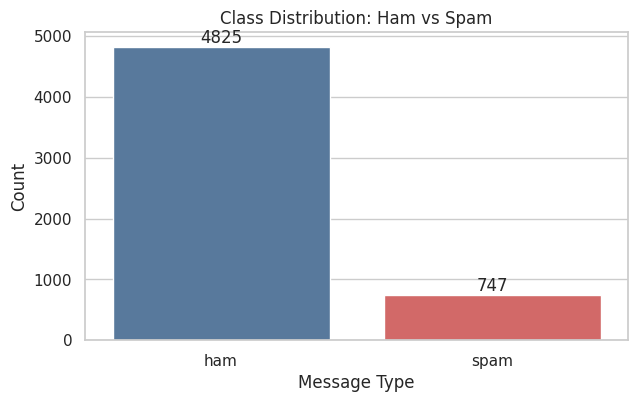

In [5]:
# Visual 1: class distribution
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=data, x='label', palette=['#4C78A8', '#E45756'])
plt.title('Class Distribution: Ham vs Spam')
plt.xlabel('Message Type')
plt.ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)
plt.show()


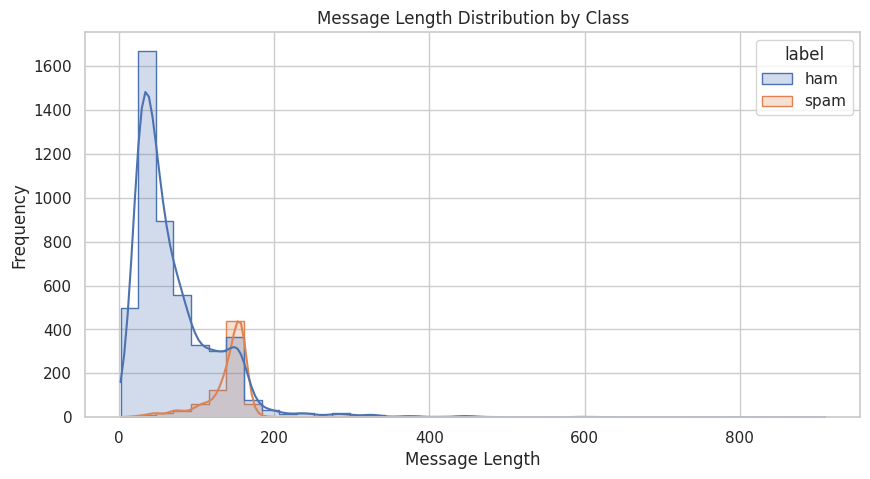

In [6]:
# Visual 2: message length comparison
plt.figure(figsize=(10, 5))
sns.histplot(data=data, x='message_length', hue='label', bins=40, kde=True, element='step')
plt.title('Message Length Distribution by Class')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.show()


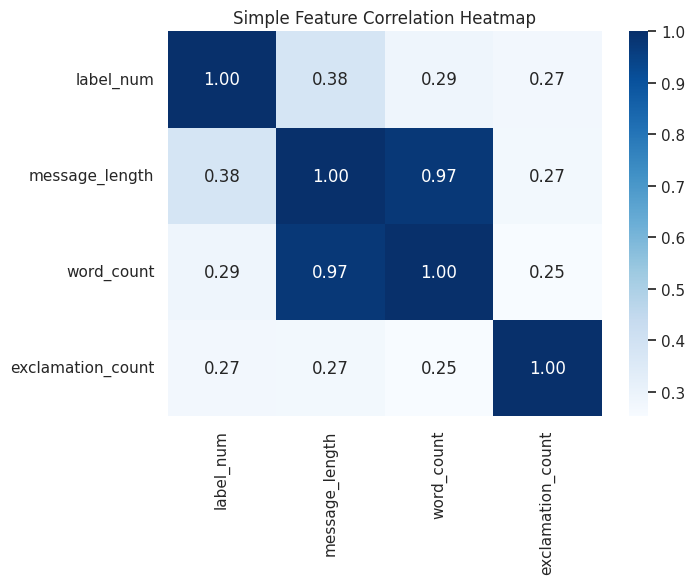

In [7]:
# Visual 3: feature relationship snapshot
feature_view = data[['label_num', 'message_length', 'word_count', 'exclamation_count']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(feature_view, annot=True, cmap='Blues', fmt='.2f')
plt.title('Simple Feature Correlation Heatmap')
plt.show()


## 3. Prepare training and test data

We now split the data so the model is evaluated on unseen messages.
This is important because a model should be judged on what it has **not** already seen.


In [8]:
# Our input is the raw message text and our target is the numeric label.
X = data['message']
y = data['label_num']

# Stratify keeps the spam/ham balance similar in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


Training samples: 4457
Testing samples: 1115


## 4. Baseline model with TF-IDF + Logistic Regression

This is the clean starting point.
TF-IDF turns text into numbers based on word importance, and Logistic Regression is a strong baseline for text classification.


In [9]:
# Convert text into TF-IDF vectors.
# max_features keeps the representation useful without growing too large.
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF train shape:', X_train_tfidf.shape)
print('TF-IDF test shape:', X_test_tfidf.shape)


TF-IDF train shape: (4457, 5000)
TF-IDF test shape: (1115, 5000)


In [10]:
# Train a baseline classifier.
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

# Predict on unseen data.
y_pred_baseline = baseline_model.predict(X_test_tfidf)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(classification_report(y_test, y_pred_baseline, target_names=['ham', 'spam']))


Baseline Accuracy: 0.9758
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       1.00      0.82      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



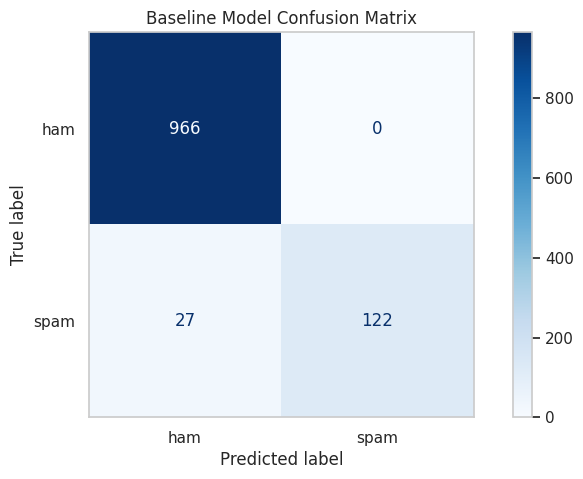

In [11]:
# Visual 4: confusion matrix for baseline model
cm = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam']).plot(cmap='Blues')
plt.title('Baseline Model Confusion Matrix')
plt.grid(False)
plt.show()


## 5. Add simple handcrafted features

This step adds a small human-style intuition layer.
We include message length, exclamation marks, and dollar signs because spam often looks more aggressive or promotional.


In [12]:
# Build very simple handcrafted features.
def simple_embedding(texts):
    return np.array([
        [
            len(text),          # total characters
            text.count('!'),    # excitement / urgency signal
            text.count('$')     # money-related signal
        ]
        for text in texts
    ])

X_train_emb = simple_embedding(X_train)
X_test_emb = simple_embedding(X_test)

print('Handcrafted feature shape:', X_train_emb.shape)


Handcrafted feature shape: (4457, 3)


In [13]:
# Combine sparse TF-IDF features with handcrafted numeric features.
X_train_combined = hstack([X_train_tfidf, X_train_emb])
X_test_combined = hstack([X_test_tfidf, X_test_emb])

baseline_plus_features = LogisticRegression(max_iter=1000)
baseline_plus_features.fit(X_train_combined, y_train)

y_pred_combined = baseline_plus_features.predict(X_test_combined)
combined_accuracy = accuracy_score(y_test, y_pred_combined)

print(f"Accuracy with handcrafted features: {combined_accuracy:.4f}")


Accuracy with handcrafted features: 0.9704


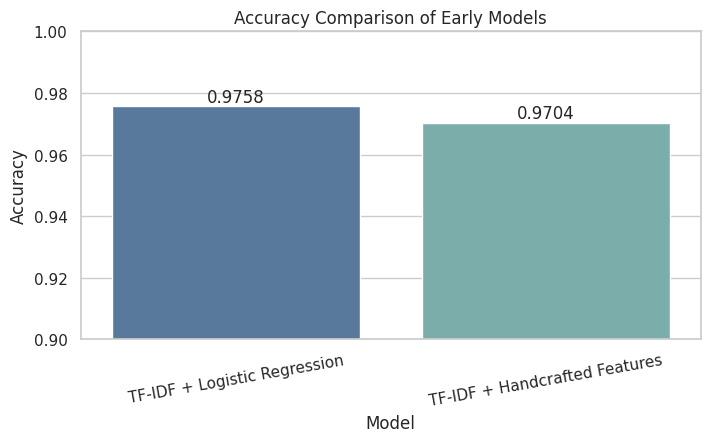

In [14]:
# Visual 5: compare the first two model versions.
comparison_df = pd.DataFrame({
    'Model': ['TF-IDF + Logistic Regression', 'TF-IDF + Handcrafted Features'],
    'Accuracy': [baseline_accuracy, combined_accuracy]
})

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=comparison_df, x='Model', y='Accuracy', palette=['#4C78A8', '#72B7B2'])
plt.ylim(0.90, 1.00)
plt.title('Accuracy Comparison of Early Models')
plt.xticks(rotation=10)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f')
plt.show()


## 6. Bring in BERT embeddings

Now we use a stronger language representation.
BERT helps us capture context much better than plain bag-of-words features, though it is slower and heavier.


In [15]:
# Load the tokenizer and pretrained BERT model.
# We use the CLS token embedding as a compact sentence-level representation.
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [16]:
# Extract BERT embeddings one text at a time.
# This is easy to understand, though not the fastest approach.
def get_bert_embeddings(texts):
    embeddings = []

    for text in texts:
        inputs = tokenizer(
            text,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=128
        )

        with torch.no_grad():
            outputs = bert_model(**inputs)

        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
        embeddings.append(cls_embedding)

    return np.array(embeddings)


In [17]:
# Generate BERT features for train and test data.
# This can take a little time depending on your machine.
X_train_bert = get_bert_embeddings(X_train.tolist())
X_test_bert = get_bert_embeddings(X_test.tolist())

print('BERT embedding shape:', X_train_bert.shape)


BERT embedding shape: (4457, 768)


### Faster BERT extraction option

The previous function is simple for learning.
This next version is more practical because it processes messages in batches.


In [18]:
# A more efficient batching version for larger datasets.
def get_bert_batch(texts, batch_size=16):
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(
            batch,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=128
        )

        with torch.no_grad():
            outputs = bert_model(**inputs)

        cls_vectors = outputs.last_hidden_state[:, 0, :].numpy()
        embeddings.extend(cls_vectors)

    return np.array(embeddings)


## 7. Final hybrid features with XGBoost

We now combine:
- TF-IDF text importance
- BERT context embeddings
- Later, optional graph-inspired text structure features

This gives us a richer representation of each message.


In [19]:
# Combine TF-IDF and BERT features into one hybrid representation.
X_train_final = hstack([X_train_tfidf, X_train_bert])
X_test_final = hstack([X_test_tfidf, X_test_bert])

print('Final hybrid feature shape:', X_train_final.shape)


Final hybrid feature shape: (4457, 5768)


In [20]:
# Train a stronger classifier on top of the hybrid features.
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train_final, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [21]:
# Evaluate the hybrid model.
y_pred = model.predict(X_test_final)
y_prob = model.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob), 4))


              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       1.00      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115

ROC-AUC: 0.9967


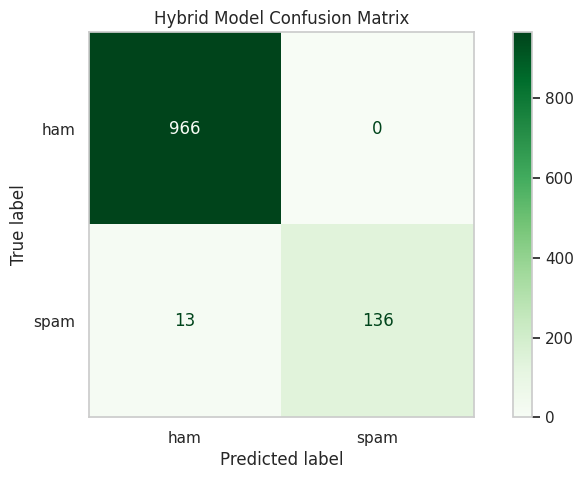

In [22]:
# Visual 6: confusion matrix for the hybrid model
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam']).plot(cmap='Greens')
plt.title('Hybrid Model Confusion Matrix')
plt.grid(False)
plt.show()


## 8. Tune the model a little

Hyperparameter tuning helps us check whether a different tree depth or number of estimators gives a better result.


In [23]:
# Small grid search for a more thoughtful model selection step.
params = {
    'max_depth': [4, 6],
    'n_estimators': [100, 200]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    params,
    cv=3,
    scoring='f1'
)
grid.fit(X_train_final, y_train)

print('Best parameters:', grid.best_params_)
print('Best CV score:', round(grid.best_score_, 4))


Best parameters: {'max_depth': 4, 'n_estimators': 100}
Best CV score: 0.949


## 9. Save the trained artifacts

Saving the models and transformers makes the project reusable later.


In [24]:
# Save the trained model and preprocessing objects.
joblib.dump(model, 'spam_model_v2.pkl')
joblib.dump(tfidf, 'tfidf.pkl')
bert_model.save_pretrained('bert_model')
tokenizer.save_pretrained('bert_tokenizer')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_tokenizer/tokenizer_config.json', 'bert_tokenizer/tokenizer.json')

## 10. Prediction helper function

This utility function shows how the saved objects can be reused for new messages.


In [25]:
def predict_spam(texts, threshold=0.5):
    # Load saved components.
    tfidf_loaded = joblib.load('tfidf.pkl')
    model_loaded = joblib.load('spam_model_v2.pkl')

    tokenizer_loaded = BertTokenizer.from_pretrained('bert_tokenizer')
    bert_loaded = BertModel.from_pretrained('bert_model')
    bert_loaded.eval()

    # Convert incoming texts into TF-IDF features.
    X_tfidf = tfidf_loaded.transform(texts)

    # Generate BERT embeddings for the same texts.
    embeddings = []
    for text in texts:
        inputs = tokenizer_loaded(
            text,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=128
        )
        with torch.no_grad():
            outputs = bert_loaded(**inputs)
        embeddings.append(outputs.last_hidden_state[:, 0, :].squeeze().numpy())

    X_bert = np.array(embeddings)
    X_final = hstack([X_tfidf, X_bert])

    # Return both the class prediction and spam probability.
    probs = model_loaded.predict_proba(X_final)[:, 1]
    preds = (probs > threshold).astype(int)
    return preds, probs


## 11. Probability calibration and threshold tuning

Sometimes we do not want to use the default `0.5` threshold.
For real spam filtering, higher precision may be more important because we do not want to mark good messages as spam too often.


In [26]:
# Calibrate probabilities so the confidence scores are more meaningful.
calibrated_model = CalibratedClassifierCV(model, method='sigmoid', cv='prefit')
calibrated_model.fit(X_train_final, y_train)
joblib.dump(calibrated_model, 'spam_model_calibrated.pkl')


['spam_model_calibrated.pkl']

In [27]:
# Precision-recall analysis helps us choose a more business-friendly threshold.
probs = calibrated_model.predict_proba(X_test_final)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Find the first threshold where precision becomes very high.
valid_positions = np.where(precision[:-1] >= 0.95)[0]
optimal_threshold = thresholds[valid_positions[0]] if len(valid_positions) > 0 else 0.5

print('Suggested threshold for high precision:', round(float(optimal_threshold), 4))


Suggested threshold for high precision: 0.0008


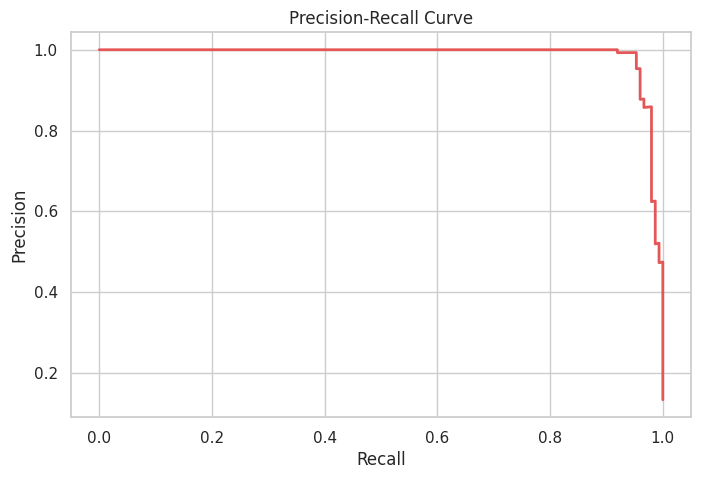

In [28]:
# Visual 7: precision-recall curve
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='#E45756', linewidth=2)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()


## 12. Model interpretation with SHAP

Interpretability helps us answer an important question:
**Why did the model think a message looked like spam?**


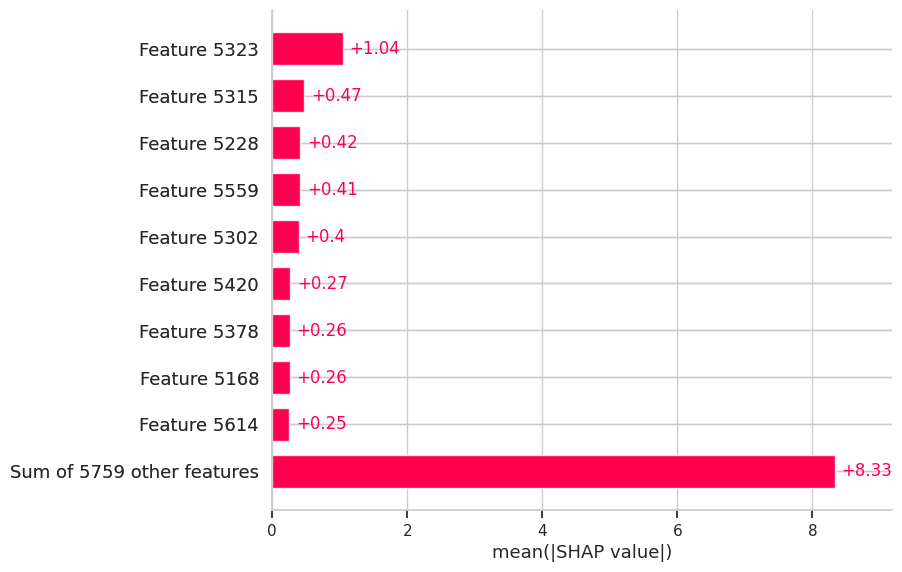

In [29]:
# SHAP can be expensive, so we only use a small sample.
# If this is slow on your machine, reduce the sample size further.
explainer = shap.Explainer(model)
shap_values = explainer(X_test_final.tocsr()[:100])
shap.plots.bar(shap_values)


## 13. Error analysis

A mature project does not stop at accuracy.
Looking at mistakes gives us practical ideas for improvement.


In [30]:
# Inspect a few messages the model got wrong.
misclassified = X_test[y_pred != y_test]
print(f'Misclassified examples: {len(misclassified)}')

for i, text in enumerate(misclassified.head(5), start=1):
    print(f'Example {i}:')
    print(text)
    print('-' * 80)


Misclassified examples: 13
Example 1:
Talk sexy!! Make new friends or fall in love in the worlds most discreet text dating service. Just text VIP to 83110 and see who you could meet.
--------------------------------------------------------------------------------
Example 2:
sexy sexy cum and text me im wet and warm and ready for some porn! u up for some fun? THIS MSG IS FREE RECD MSGS 150P INC VAT 2 CANCEL TEXT STOP
--------------------------------------------------------------------------------
Example 3:
it to 80488. Your 500 free text messages are valid until 31 December 2005.
--------------------------------------------------------------------------------
Example 4:
ringtoneking 84484
--------------------------------------------------------------------------------
Example 5:
Latest News! Police station toilet stolen, cops have nothing to go on!
--------------------------------------------------------------------------------


## 14. Graph-inspired text features

This is a creative extra step.
We treat a message like a tiny word graph and capture simple structure information such as:
- number of unique words
- number of edges between consecutive words
- graph density-like ratio


In [31]:
def graph_features(texts):
    features = []

    for text in texts:
        words = text.split()
        edges = set()

        # Connect each word to the next one to form a simple chain graph.
        for i in range(len(words) - 1):
            edges.add((words[i], words[i + 1]))

        num_nodes = len(set(words))
        num_edges = len(edges)
        density = num_edges / (num_nodes + 1)

        features.append([num_nodes, num_edges, density])

    return np.array(features)


In [32]:
# Add graph-style features to the previous hybrid representation.
X_train_graph = graph_features(X_train)
X_test_graph = graph_features(X_test)

X_train_graph_final = hstack([X_train_tfidf, X_train_bert, X_train_graph])
X_test_graph_final = hstack([X_test_tfidf, X_test_bert, X_test_graph])

print('Graph-augmented feature shape:', X_train_graph_final.shape)


Graph-augmented feature shape: (4457, 5771)


In [33]:
# Train and evaluate one more version with graph-inspired features.
graph_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
graph_model.fit(X_train_graph_final, y_train)

y_pred_graph = graph_model.predict(X_test_graph_final)
graph_accuracy = accuracy_score(y_test, y_pred_graph)

print(f'Graph-augmented accuracy: {graph_accuracy:.4f}')


Graph-augmented accuracy: 0.9883


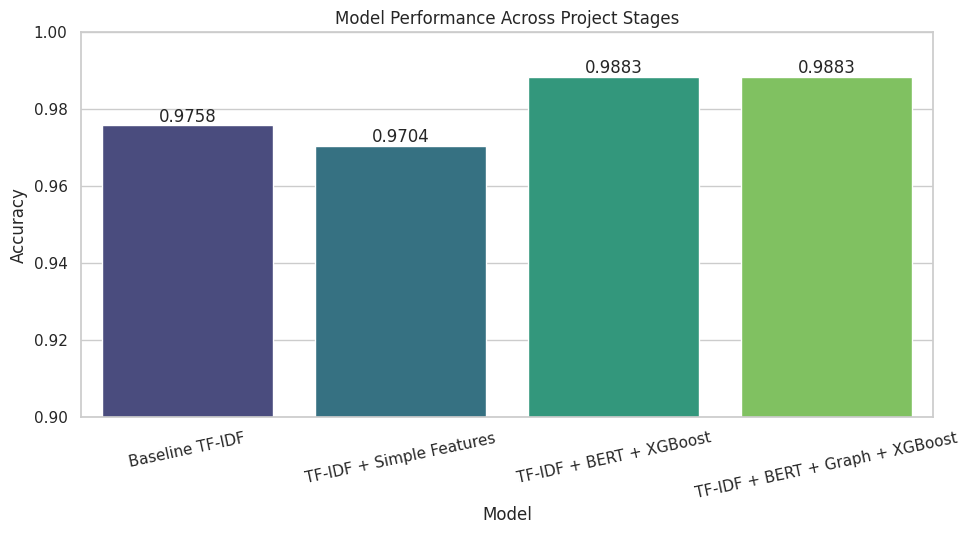

In [34]:
# Visual 8: final comparison across model stages
final_comparison = pd.DataFrame({
    'Model': [
        'Baseline TF-IDF',
        'TF-IDF + Simple Features',
        'TF-IDF + BERT + XGBoost',
        'TF-IDF + BERT + Graph + XGBoost'
    ],
    'Accuracy': [
        baseline_accuracy,
        combined_accuracy,
        accuracy_score(y_test, y_pred),
        graph_accuracy
    ]
})

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=final_comparison, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Performance Across Project Stages')
plt.xticks(rotation=12)
plt.ylim(0.90, 1.00)
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f')
plt.show()
